In [24]:
import os
import json
import numpy as np
import pandas as pd

from dataclasses import dataclass

In [25]:
MANIFEST_PATH = "live_eeg_dataset/manifest.csv"
ANNOTATIONS_PATH = "live_eeg_dataset/seizure_annotations.csv"

LABELED_MANIFEST_PATH = "live_eeg_dataset/labeled_manifest.csv"
TRAINING_MANIFEST_PATH = "live_eeg_dataset/training_manifest.csv"

PREICTAL_SEC = 10 * 60
POSTICTAL_EXCLUSION_SEC = 30 * 60
INTERICTAL_GAP_SEC = 5 * 60

KEEP_ONLY_QC_PASS = True
TRAINING_LABELS = {"preictal", "interictal"}
@dataclass
class SeizureEvent:
    session_id: str
    seizure_start: float
    seizure_end: float

In [26]:
def safe_json_load(x):
    if pd.isna(x):
        return None
    if isinstance(x, (list, dict)):
        return x
    try:
        return json.loads(x)
    except Exception:
        return x


def load_manifest(manifest_path):
    df = pd.read_csv(manifest_path)

    for col in ["channel_order", "qc_details", "skipped_pairs"]:
        if col in df.columns:
            df[col] = df[col].apply(safe_json_load)

    for col in ["timestamp_start", "timestamp_end", "fs", "n_channels", "n_samples"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "qc_pass" in df.columns:
        df["qc_pass"] = df["qc_pass"].astype(bool)

    return df

In [27]:
def load_annotations(annotations_path):
    ann = pd.read_csv(annotations_path)

    required = {"session_id", "seizure_start", "seizure_end"}
    missing = required - set(ann.columns)
    if missing:
        raise ValueError(f"Missing required annotation columns: {missing}")

    ann["seizure_start"] = pd.to_numeric(ann["seizure_start"], errors="coerce")
    ann["seizure_end"] = pd.to_numeric(ann["seizure_end"], errors="coerce")

    ann = ann.dropna(subset=["session_id", "seizure_start", "seizure_end"]).copy()
    ann = ann.sort_values(["session_id", "seizure_start"]).reset_index(drop=True)

    return ann

In [28]:
def overlaps(a_start, a_end, b_start, b_end):
    return a_start < b_end and a_end > b_start


def label_window(
    window_start,
    window_end,
    seizure_starts,
    seizure_ends,
    preictal_sec: int = PREICTAL_SEC,
    postictal_exclusion_sec: int = POSTICTAL_EXCLUSION_SEC,
    interictal_gap_sec: int = INTERICTAL_GAP_SEC
):
    for s, e in zip(seizure_starts, seizure_ends):
        if overlaps(window_start, window_end, s, e):
            return "ictal"

    for s in seizure_starts:
        if s - preictal_sec <= window_start < s:
            return "preictal"

    for e in seizure_ends:
        if e <= window_start < e + postictal_exclusion_sec:
            return "exclude"

    far_from_all = True
    for s, e in zip(seizure_starts, seizure_ends):
        if abs(window_start - s) < interictal_gap_sec:
            far_from_all = False
            break
        if abs(window_end - e) < interictal_gap_sec:
            far_from_all = False
            break

    if far_from_all:
        return "interictal"

    return "exclude"

In [29]:
def label_manifest(
    manifest_df,
    annotations_df
):
    if "session_id" not in manifest_df.columns:
        raise ValueError(
            "Manifest must contain a session_id column for session-aware labeling."
        )

    labeled_rows = []

    for session_id, session_df in manifest_df.groupby("session_id"):
        ann = annotations_df[annotations_df["session_id"] == session_id]

        seizure_starts = ann["seizure_start"].tolist()
        seizure_ends = ann["seizure_end"].tolist()

        for _, row in session_df.iterrows():
            row_dict = row.to_dict()

            if len(seizure_starts) == 0:
                row_dict["label"] = "interictal"
                row_dict["label_reason"] = "no_seizures_in_session"
            else:
                label = label_window(
                    window_start=row_dict["timestamp_start"],
                    window_end=row_dict["timestamp_end"],
                    seizure_starts=seizure_starts,
                    seizure_ends=seizure_ends
                )
                row_dict["label"] = label
                row_dict["label_reason"] = "rule_based_time_alignment"

            labeled_rows.append(row_dict)

    labeled_df = pd.DataFrame(labeled_rows)
    labeled_df = labeled_df.sort_values(["session_id", "timestamp_start"]).reset_index(drop=True)
    return labeled_df

In [30]:
def build_training_manifest(
    labeled_df,
    keep_only_qc_pass: bool = KEEP_ONLY_QC_PASS,
    training_labels: set = TRAINING_LABELS
):
    df = labeled_df.copy()

    if keep_only_qc_pass and "qc_pass" in df.columns:
        df = df[df["qc_pass"] == True].copy()

    df = df[df["label"].isin(training_labels)].copy()

    df["target"] = (df["label"] == "preictal").astype(int)

    df["window_duration_sec"] = df["timestamp_end"] - df["timestamp_start"]
    df["window_midpoint"] = (df["timestamp_start"] + df["timestamp_end"]) / 2.0

    df = df.reset_index(drop=True)
    return df

In [31]:
def load_feature_matrix(training_df):
    X = np.vstack([np.load(path) for path in training_df["feature_path"]])
    y = training_df["target"].values.astype(int)
    return X, y


def load_raw_window_matrix(training_df: pd.DataFrame):
    X = np.stack([
        np.load(path, allow_pickle=True)["window"]
        for path in training_df["file_path"]
    ])
    y = training_df["target"].values.astype(int)
    return X, y

In [32]:
def summarize_dataframe(df, name):
    summary = {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values_total": int(df.isna().sum().sum()),
    }

    if "label" in df.columns:
        vc = df["label"].value_counts(dropna=False).to_dict()
        for k, v in vc.items():
            summary[f"label_{k}"] = int(v)

    if "target" in df.columns:
        vc = df["target"].value_counts(dropna=False).to_dict()
        for k, v in vc.items():
            summary[f"target_{k}"] = int(v)

    return pd.DataFrame([summary])

In [33]:
def run_phase2_labeling():
    manifest_df = load_manifest(MANIFEST_PATH)
    annotations_df = load_annotations(ANNOTATIONS_PATH)

    labeled_df = label_manifest(manifest_df, annotations_df)
    training_df = build_training_manifest(labeled_df)

    labeled_df.to_csv(LABELED_MANIFEST_PATH, index=False)
    training_df.to_csv(TRAINING_MANIFEST_PATH, index=False)

    print("Saved labeled manifest:", LABELED_MANIFEST_PATH)
    print("Saved training manifest:", TRAINING_MANIFEST_PATH)

    print("\n--- Summary: Raw Manifest ---")
    print(summarize_dataframe(manifest_df, "raw_manifest").to_string(index=False))

    print("\n--- Summary: Labeled Manifest ---")
    print(summarize_dataframe(labeled_df, "labeled_manifest").to_string(index=False))

    print("\n--- Summary: Training Manifest ---")
    print(summarize_dataframe(training_df, "training_manifest").to_string(index=False))

    return manifest_df, annotations_df, labeled_df, training_df

In [34]:
if __name__ == "__main__":
    run_phase2_labeling()

Saved labeled manifest: live_eeg_dataset/labeled_manifest.csv
Saved training manifest: live_eeg_dataset/training_manifest.csv

--- Summary: Raw Manifest ---
     dataset  rows  columns  missing_values_total
raw_manifest   470       14                     0

--- Summary: Labeled Manifest ---
         dataset  rows  columns  missing_values_total  label_exclude  label_interictal  label_preictal  label_ictal
labeled_manifest   470       16                     0            351                89              18           12

--- Summary: Training Manifest ---
          dataset  rows  columns  missing_values_total  label_interictal  label_preictal  target_0  target_1
training_manifest   107       19                     0                89              18        89        18


In [35]:
import pandas as pd

train_df = pd.read_csv("live_eeg_dataset/training_manifest.csv")
print(train_df["target"].value_counts())
print(train_df[["label", "target"]].head())

target
0    89
1    18
Name: count, dtype: int64
      label  target
0  preictal       1
1  preictal       1
2  preictal       1
3  preictal       1
4  preictal       1


In [36]:
import numpy as np




X = np.vstack([np.load(path) for path in train_df["feature_path"]])
y = train_df["target"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class counts:", pd.Series(y).value_counts().to_dict())

X shape: (107, 80)
y shape: (107,)
Class counts: {0: 89, 1: 18}


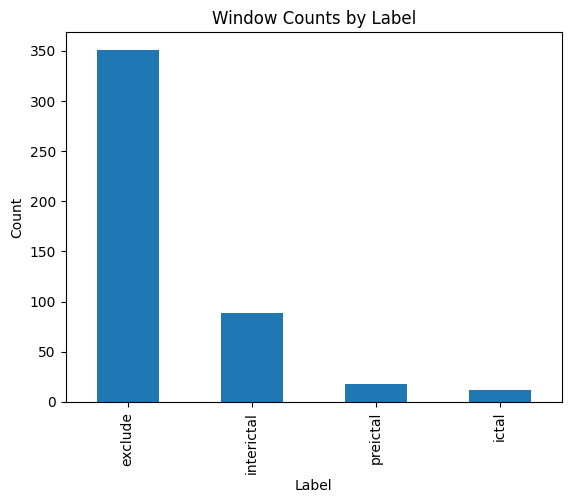

In [37]:
import matplotlib.pyplot as plt

labeled_df = pd.read_csv("live_eeg_dataset/labeled_manifest.csv")
labeled_df["label"].value_counts().plot(kind="bar")
plt.title("Window Counts by Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


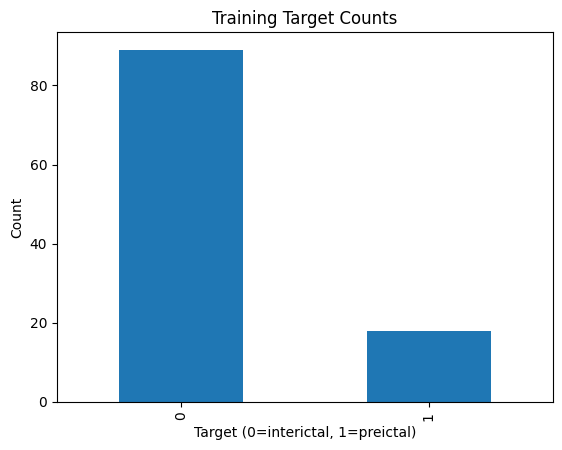

In [38]:
train_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Target Counts")
plt.xlabel("Target (0=interictal, 1=preictal)")
plt.ylabel("Count")
plt.show()

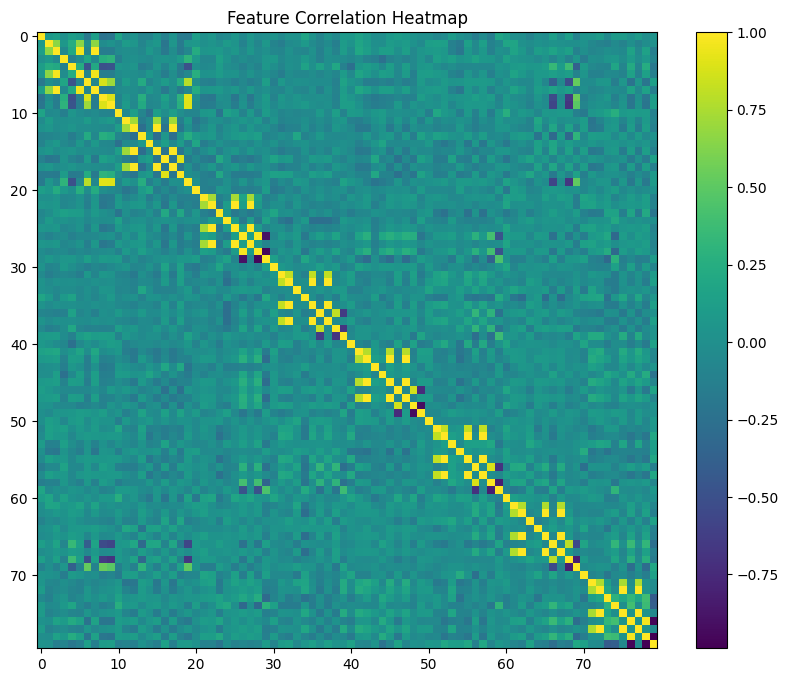

In [42]:
X_df = pd.DataFrame(X)
corr = X_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.title("Feature Correlation Heatmap")
plt.colorbar()
plt.show()

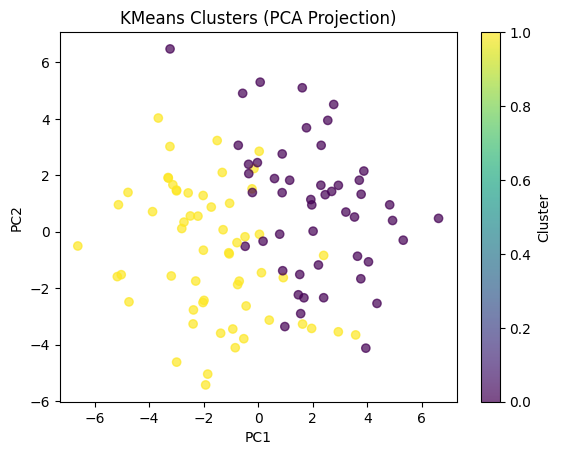

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

train_df = pd.read_csv("live_eeg_dataset/training_manifest.csv")

X = np.vstack([np.load(p) for p in train_df["feature_path"]])
y = train_df["target"].values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, alpha=0.7)
plt.title("KMeans Clusters Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

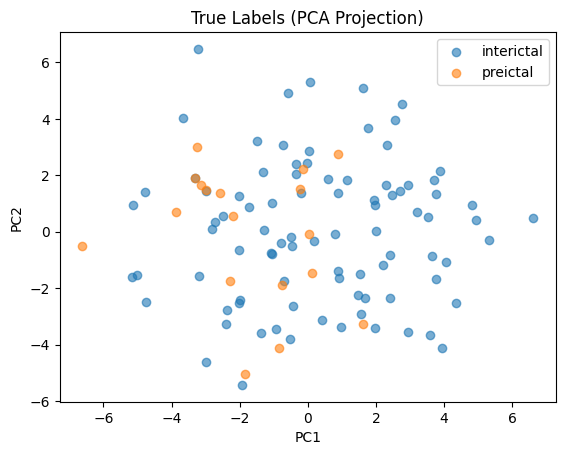

In [ ]:
plt.figure()

plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.6, label="interictal")
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.6, label="preictal")

plt.title("True Labels (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()